<a href="https://colab.research.google.com/github/404error-notfound/Data-Wrangling/blob/main/Airplane_Crashes_Data_Cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**GROUP MEMBERS**
1. KOI JOYJUDY - 168974
2. ANGELA OMONDI - 189545
3. EMMANUEL MUNDIA - 189225

In [ ]:
import pandas as pd

In [ ]:
upload =
df = pd.read_csv('/Airplane_Crashes_and_Fatalities_Since_1908.csv')

In [ ]:
#cell 1 - Question 2 : number of rows and columns

import pandas as pd

df = pd.read_csv("/Airplane_Crashes_and_Fatalities_Since_1908.csv")

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 5268
Number of columns: 13


In [ ]:
#cell 2 - Question 3 : displaying the last 75 rows of the data set
import pandas as pd

df = pd.read_csv('/Airplane_Crashes_and_Fatalities_Since_1908.csv')

pd.set_option('display.max_rows', 75)
pd.set_option('display.max_columns', None)

last_rows = df.tail(75)

last_rows

,Date,Time,Location,Operator,Flight #,Route,Type,Registration,cn/In,Aboard,Fatalities,Ground,Summary
5193,03/15/2008,08:15,"Nbagu, Nigeria",Trade Wings Aviation Ltd.,NaN,Lagos - Bebi Air Strip,Beechcraft 1900D,5N-JAH,UE-322,3.0,3.0,0.0,The plane crashed while en route. Wreckage was...
5194,04/03/2008,11:00,"Lawa, Suriname",Blue Wing Airlines,NaN,Paramaribo - Lawa,Antonov An-28,PZ-TSO,1AJ007-17,19.0,19.0,0.0,While attempting to land the crew aborted the ...
5195,04/09/2008,23:27,"Bundeena, Australia",Avtex Air Services,NaN,Sydney - Brisbane,Swearingen SA227AC Metroliner III,VH-OZA,AC-600,1.0,1.0,0.0,The pilot of the mail plane reported some mino...
5196,04/11/2008,22:15,"Chrisinau, Moldova",Kata Transportation,NaN,"Chrisinau, Moldova - Antalya, Turkey - Sudan",Antonov An-32,ST-AZL,3009,8.0,8.0,0.0,Just minutes after the take off the plane trie...
5197,04/15/2008,14:30,"Goma, Congo",Hewa Bora Airways,NaN,Goma - Kisangani - Kinshasa,McDonnell Douglas DC-9-51,9Q-CHN,47731,85.0,0.0,47.0,"While attempting to takeoff, the plane failed ..."
5198,04/16/2008,14:23,"Off Annobon Island, Equatorial Guinea",Military - Government of Equatorial Guinea,NaN,Bata - Annobon Island,Antonov An-32B,3C-5GE,1609,13.0,13.0,0.0,Crashed into the ocean after skidding off the ...
5199,04/28/2008,09:38,"Off Crimea, Black Sea",Naftogaz,NaN,NaN,Mil Mi-8T,UR-24275,98734295,20.0,20.0,0.0,The helicopter crashed after the tail section ...
5200,05/02/2008,10:10,"Near Rumbek, Sudan",Southern Sudan Air Connection,NaN,Wau - Rumbek - Juba,Beechcraft 1900C,5Y-FLX,UC-65,24.0,24.0,0.0,The pilot radioed a control tower in the city ...
5201,05/17/2008,16:30,"Stehekin, Washington",Chelan Air Service,NaN,Chelan - Stehekin,de Havilland Canada DHC-2 Mark I Beaver,N5998Q,1151,5.0,2.0,0.0,The float plane flipped and crashed as it atte...
5202,05/23/2008,01:25,"Billings, Montana",Alpine Aviation,5008,Billings - Great Falls,Beechcraft 1900C,N195GA,U-65,1.0,1.0,0.0,"After taking off and being told to turn left,..."


In [ ]:
from typing_extensions import Type
#cell 3 - Question 4: Method of treating the missing data

#List all column names
list(df.columns)

['Date',
 'Time',
 'Location',
 'Operator',
 'Flight #',
 'Route',
 'Type',
 'Registration',
 'cn/In',
 'Aboard',
 'Fatalities',
 'Ground',
 'Summary']



1.   Time: Drop rows. Reason: Values are scattered.

2. Location: Drop rows with missing values. Reason: the data is scattered

3. Operator: refine at the business understanding stage. Reason: the missing data is probably related to another variable

4. Flight: drop rows with missing values. Reason: The data is scattered

5. Route: refine at the business understanding stage. Reason: the missing data is probably related to another variable

6. Type: refine at the business understanding stage. Reason: the missing data is probably related to another variable

7. Registration: refine at the business understanding stage. Reason: the missing data is probably related to another variable

8. cn/In: Drop rows with missing values. Reason: the data is scattered.

9. Aboard: imputation using mean/mode/median of the column. Reason: seems like important information

10. Fatalities: imputation using mean/mode/median of the column. Reason: seems like important information

11. Ground: imputaiton using mean/mode/median of the column. Reason: Seems like important information

12. Summary: drop rows with missing data.
Reason: There is likely no relationship between the missing data and other recorded values.

In [ ]:
#cell 4 - Question 5
fatality_locations = df[['Date', 'Location', 'Aboard', 'Fatalities']].copy()

In [ ]:
#cell 5 - Question 6
highest_fatalityrow= fatality_locations.loc[fatality_locations['Fatalities'].idxmax()]
print(highest_fatalityrow)

Date                        03/27/1977
Location      Tenerife, Canary Islands
Aboard                           644.0
Fatalities                       583.0
Name: 2963, dtype: object


In [ ]:
#cell 6 - Question 7
#Comparing the number of passengers aboard to fatalities per crash
total_aboard = fatality_locations['Aboard'].sum()
total_fatalities = fatality_locations['Fatalities'].sum()
fatality_rate = total_fatalities / total_aboard
print("Total passengers aboard: ", total_aboard)
print("Total fatalities: ", total_fatalities)
print("Fatality rate: ", fatality_rate, "%")
#Total crashes with zero fatalities
zero_fatalities= (fatality_locations['Fatalities'] == 0).sum()
print("Total crashes with zero fatalities: ", zero_fatalities)

Total passengers aboard:  144551.0
Total fatalities:  105479.0
Fatality rate:  0.7297009360018264 %
Total crashes with zero fatalities:  58


In [ ]:
#cell 7 - Question 8 Splitting the location column
import pandas as pd

#Split on the first comma only
fatality_locations[['Region', 'State/Country']] = (fatality_locations['Location'].str.split(',', n=1, expand=True))
#Strip leading/trailing whitespace from both new columns
fatality_locations['Region'] = fatality_locations['Region'].str.strip()
fatality_locations['State/Country'] = fatality_locations['State/Country'].str.strip()



fatality_locations.head(75)

,Date,Location,Aboard,Fatalities,Region,State/Country
0,09/17/1908,"Fort Myer, Virginia",2.0,1.0,Fort Myer,Virginia
1,07/12/1912,"AtlantiCity, New Jersey",5.0,5.0,AtlantiCity,New Jersey
2,08/06/1913,"Victoria, British Columbia, Canada",1.0,1.0,Victoria,"British Columbia, Canada"
3,09/09/1913,Over the North Sea,20.0,14.0,Over the North Sea,None
4,10/17/1913,"Near Johannisthal, Germany",30.0,30.0,Near Johannisthal,Germany
5,03/05/1915,"Tienen, Belgium",41.0,21.0,Tienen,Belgium
6,09/03/1915,"Off Cuxhaven, Germany",19.0,19.0,Off Cuxhaven,Germany
7,07/28/1916,"Near Jambol, Bulgeria",20.0,20.0,Near Jambol,Bulgeria
8,09/24/1916,"Billericay, England",22.0,22.0,Billericay,England
9,10/01/1916,"Potters Bar, England",19.0,19.0,Potters Bar,England


In [ ]:
#cell 8 - Question 9

#Sort the top 100 fatalities in descending order
top_100_fatalities = fatality_locations.sort_values(by='Fatalities', ascending=False).head(100)

top_100_fatalities

,Date,Location,Aboard,Fatalities,Region,State/Country
2963,03/27/1977,"Tenerife, Canary Islands",644.0,583.0,Tenerife,Canary Islands
3568,08/12/1985,"Mt. Osutaka, near Ueno Village, Japan",524.0,520.0,Mt. Osutaka,"near Ueno Village, Japan"
4455,11/12/1996,"Near Charkhidadri, India",349.0,349.0,Near Charkhidadri,India
2726,03/03/1974,"Near Ermenonville, France",346.0,346.0,Near Ermenonville,France
3562,06/23/1985,"AtlantiOcean, 110 miles West of Ireland",329.0,329.0,AtlantiOcean,110 miles West of Ireland
...,...,...,...,...,...,...
4852,04/15/2002,"Busan, South Korea",166.0,128.0,Busan,South Korea
3198,01/21/1980,"Elburz Mtns., near Laskarak, Markazi, Iran",128.0,128.0,Elburz Mtns.,"near Laskarak, Markazi, Iran"
1701,12/16/1960,"Staten Island / Brooklyn, New York",128.0,128.0,Staten Island / Brooklyn,New York
5108,07/09/2006,"Irkutsk, Russia",203.0,128.0,Irkutsk,Russia


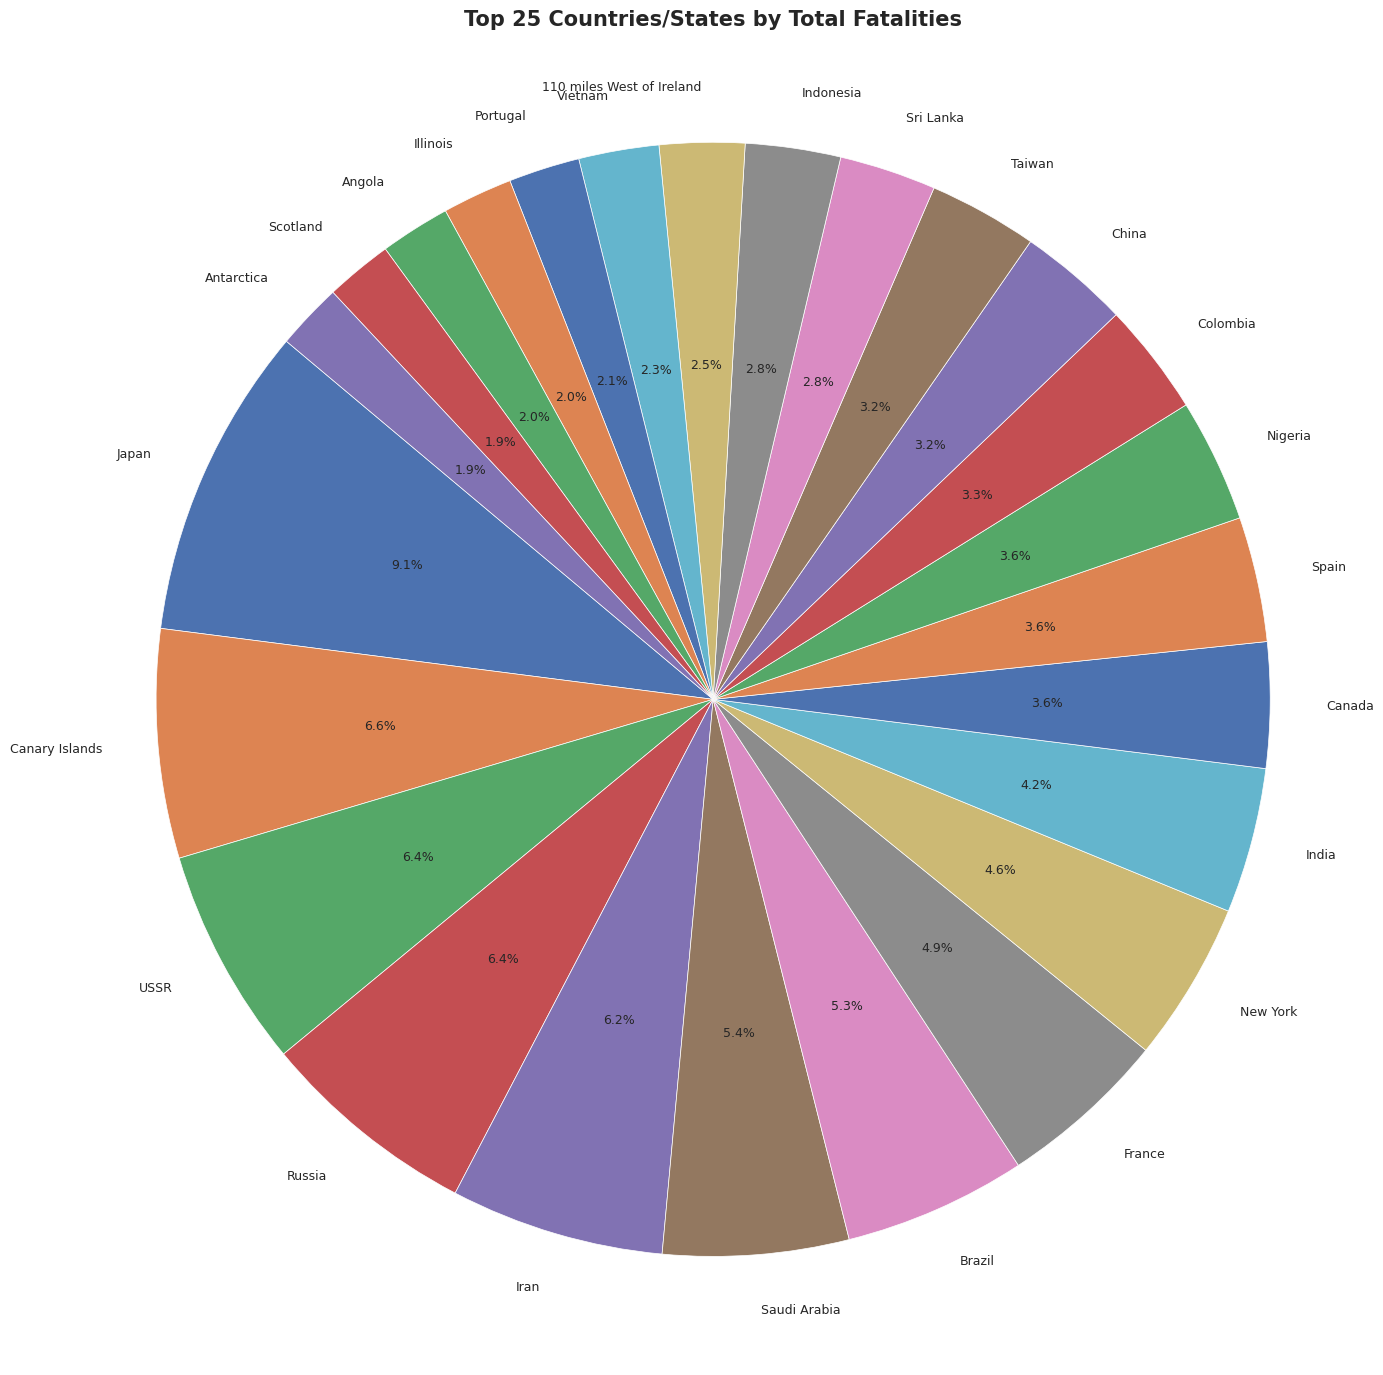

In [ ]:
#cell 9 - Question 10

import seaborn as sns
import matplotlib.pyplot as plt

#Extract the last comma-seperated segment as Country/State
top_100_fatalities['Country/State'] = (top_100_fatalities['State/Country'].str.split(',').str[-1].str.strip())
#Aggregate fatalities per country/state
country_fatalities = (top_100_fatalities.groupby('Country/State', as_index=False)['Fatalities'].sum().sort_values(by='Fatalities', ascending=False))
#Pick the top 25
top25 = country_fatalities.head(25)

sns.set_theme(style="white")

plt.figure(figsize=(14,14))
plt.pie(top25['Fatalities'],labels=top25['Country/State'],autopct='%1.1f%%',startangle=140,textprops={'fontsize': 9},wedgeprops={'edgecolor': 'white', 'linewidth': 0.5})
plt.title('Top 25 Countries/States by Total Fatalities', fontsize=15, fontweight='bold')
plt.axis('equal')
plt.tight_layout()
plt.show()



**GROUP PHOTO**😝
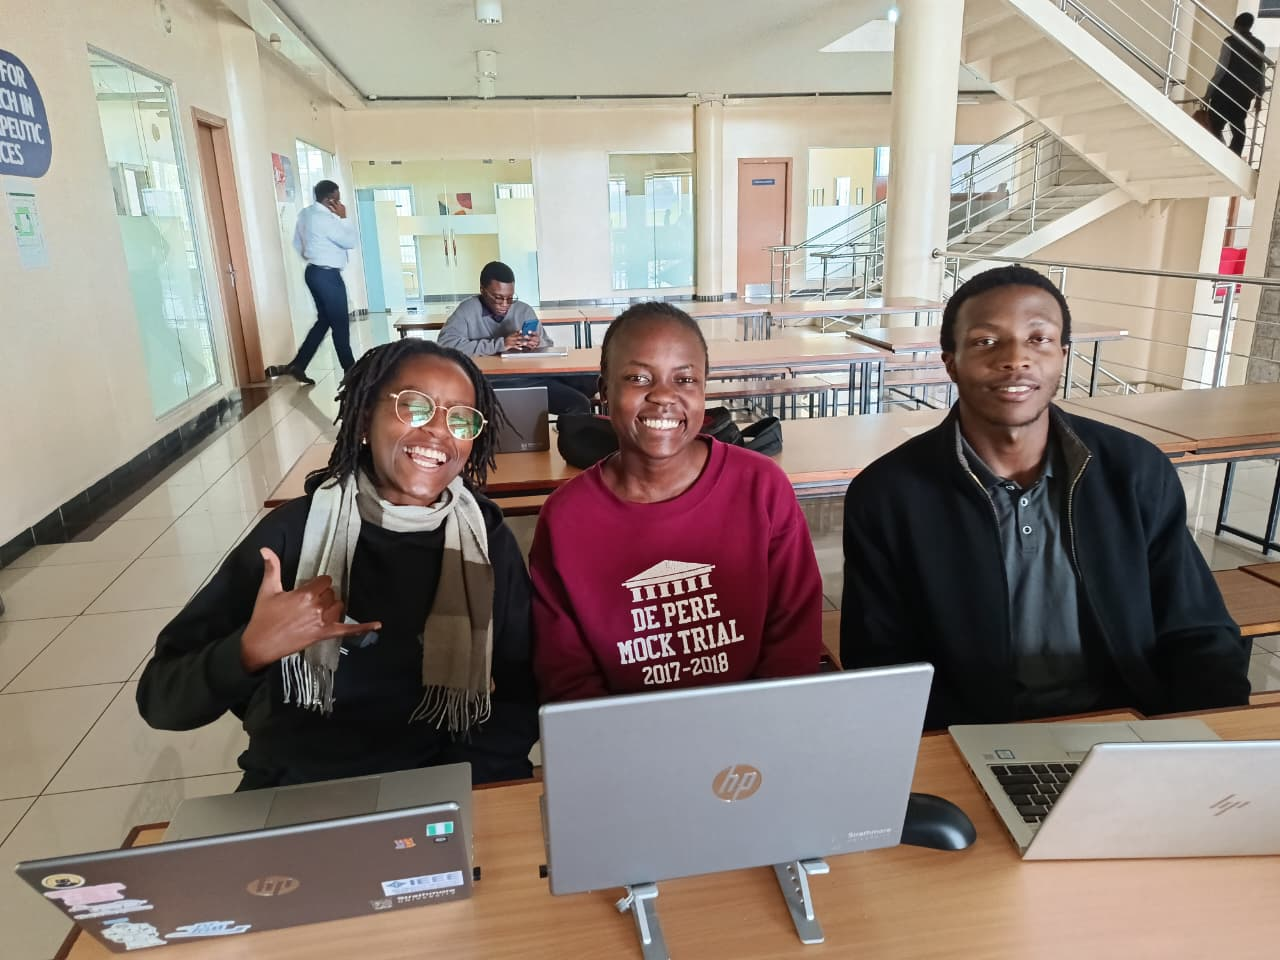